# BSPF 1D Integration Example

This notebook mirrors the simplified 1D differentiation example, but applies the inverse operation.

We sample the exact first derivative of the same test signal and recover the original signal with the BSPF antiderivative.

## Environment Setup

The next cell makes the notebook runnable directly from the repository checkout without requiring an editable install first.

In [1]:
from pathlib import Path
import sys

cwd = Path.cwd().resolve()
REPO_ROOT = next((parent for parent in (cwd, *cwd.parents) if (parent / "pyproject.toml").exists()), cwd)
SRC_ROOT = REPO_ROOT / "src"

for candidate in (SRC_ROOT, REPO_ROOT):
    candidate_str = str(candidate)
    if candidate_str not in sys.path:
        sys.path.insert(0, candidate_str)

REPO_ROOT

PosixPath('/Users/moulin/Workspace/pybspf/examples/operation')

## Imports

We use the package API directly through `BSPF1D`.

In [2]:
import matplotlib.pyplot as plt
import numpy as np

from pybspf import BSPF1D

## Problem Definition

We reuse the same nonlinear phase signal

$$
f(x) = \sin\left(\frac{x}{\beta + \cos(x)}\right)
$$

and treat integration as the inverse problem: starting from the analytical derivative $f'(x)$, we recover $f(x)$ by enforcing the left endpoint value.

In [3]:
degree = 8
reg_param = 1.0e-3
beta = 1.05
domain = (0.0, 2.0 * np.pi)
num_points = 1001
num_boundary_points = degree + 5
n_basis = 4 * degree
use_clustering = True
clustering_factor = 2.0

In [4]:
def signal(x: np.ndarray, beta: float) -> np.ndarray:
    phase = x / (beta + np.cos(x))
    return np.sin(phase)


def signal_derivative(x: np.ndarray, beta: float) -> np.ndarray:
    denom = beta + np.cos(x)
    phase = x / denom
    dphase = (denom + x * np.sin(x)) / (denom**2)
    return np.cos(phase) * dphase


def relative_linf_error(approx: np.ndarray, exact: np.ndarray) -> float:
    return float(np.max(np.abs(approx - exact)) / np.max(np.abs(exact)))

## Single Run On A Uniform Grid

In [5]:
x = np.linspace(domain[0], domain[1], num_points)
y_exact = signal(x, beta)
y_prime = signal_derivative(x, beta)
left_value = float(y_exact[0])

model = BSPF1D.from_grid(
    degree=degree,
    x=x,
    n_basis=n_basis,
    domain=domain,
    use_clustering=use_clustering,
    clustering_factor=clustering_factor,
    order=degree,
    num_boundary_points=num_boundary_points,
    correction="spectral",
)

y_antideriv_bspf, y_spline = model.antiderivative(y_prime, order=1, left_value=left_value, lam=reg_param)
initial_relative_error = relative_linf_error(y_antideriv_bspf, y_exact)
initial_relative_error

4.699307628665491e-13

## Convergence Sweep

This repeats the same basic convergence study while measuring how accurately the antiderivative recovers the original signal.

In [6]:
grid_sizes = np.geomspace(100, 1000, 50).astype(int)
relative_errors = []
delta_x_values = []

for n_points in grid_sizes:
    x_test = np.linspace(domain[0], domain[1], n_points)
    y_exact_test = signal(x_test, beta)
    y_prime_test = signal_derivative(x_test, beta)
    left_value_test = float(y_exact_test[0])

    model_test = BSPF1D.from_grid(
        degree=degree,
        x=x_test,
        n_basis=n_basis,
        domain=domain,
        use_clustering=use_clustering,
        clustering_factor=clustering_factor,
        order=degree,
        num_boundary_points=num_boundary_points,
        correction="spectral",
    )
    y_antideriv_test, _ = model_test.antiderivative(
        y_prime_test,
        order=1,
        left_value=left_value_test,
        lam=reg_param,
    )

    relative_errors.append(relative_linf_error(y_antideriv_test, y_exact_test))
    delta_x_values.append((domain[1] - domain[0]) / (n_points - 1))

relative_errors = np.array(relative_errors, dtype=np.float64)
delta_x_values = np.array(delta_x_values, dtype=np.float64)
relative_errors[:5]

array([19.94132016, 17.36938967, 24.24557832, 24.24006242, 28.74947887])

## Plot

The figure below summarizes the inverse operation directly in the notebook:

- derivative samples and spline fit,
- exact signal and BSPF antiderivative,
- pointwise relative error,
- convergence sweep.

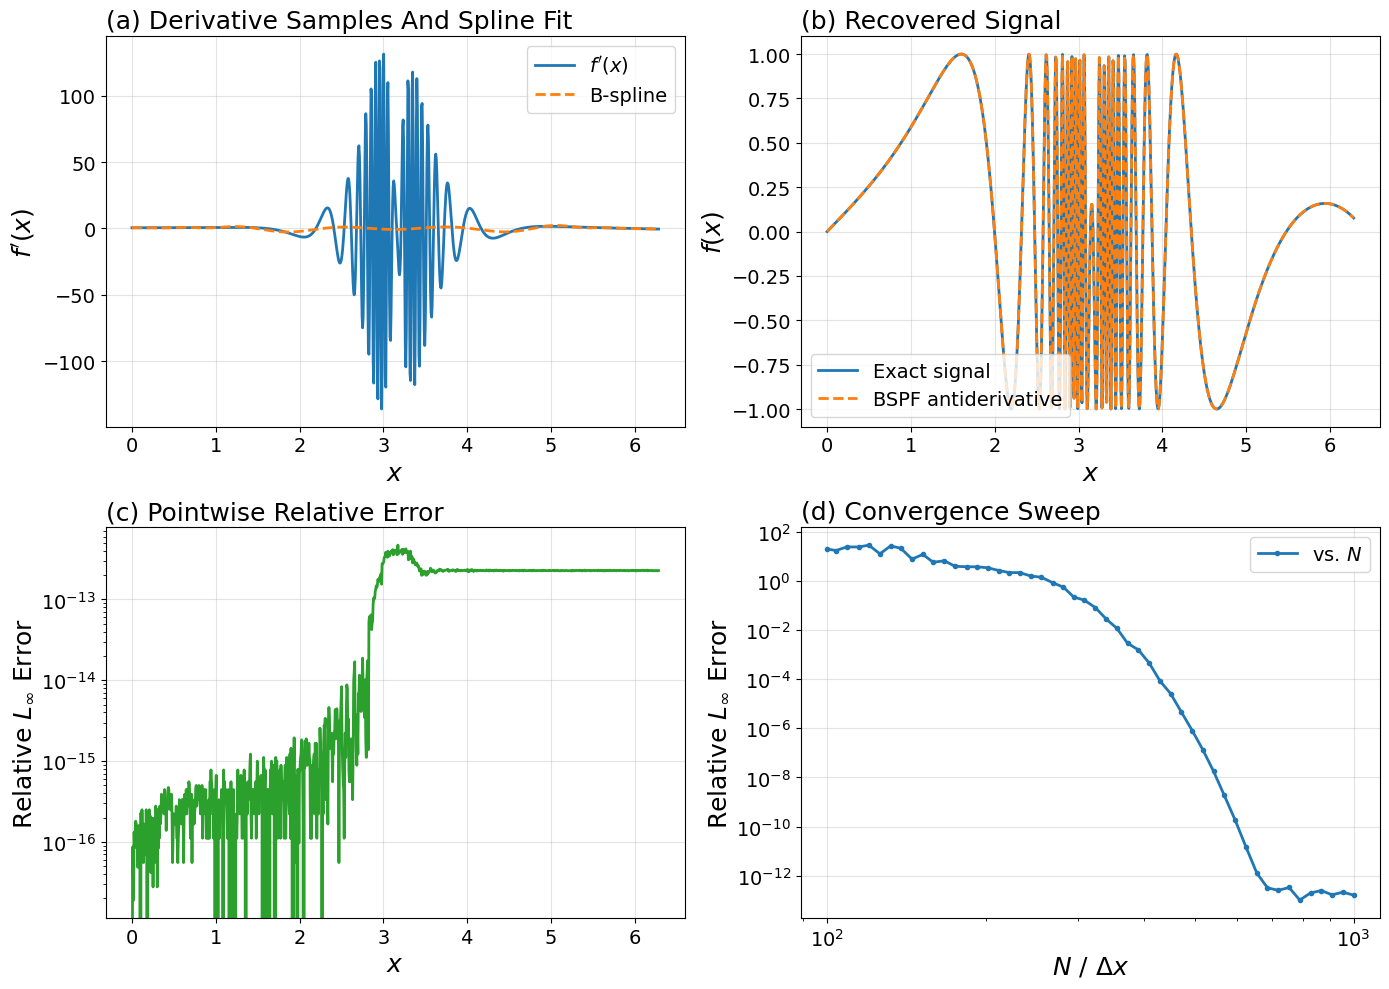

In [7]:
pointwise_relative_error = np.abs(y_antideriv_bspf - y_exact) / np.max(np.abs(y_exact))

plt.rcParams.update(
    {
        "axes.labelsize": 18,
        "axes.titlesize": 18,
        "xtick.labelsize": 14,
        "ytick.labelsize": 14,
        "legend.fontsize": 14,
        "figure.titlesize": 18,
        "axes.grid": True,
        "grid.alpha": 0.35,
    }
)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
default_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

ax = axes[0, 0]
ax.plot(x, y_prime, "-", color=default_colors[0], linewidth=2.0, label="$f'(x)$")
ax.plot(x, y_spline, "--", color=default_colors[1], linewidth=2.0, label="B-spline")
ax.set_xlabel("$x$")
ax.set_ylabel("$f'(x)$")
ax.set_title("(a) Derivative Samples And Spline Fit", loc="left")
ax.legend(loc="best")

ax = axes[0, 1]
ax.plot(x, y_exact, "-", color=default_colors[0], linewidth=2.0, label="Exact signal")
ax.plot(x, y_antideriv_bspf, "--", color=default_colors[1], linewidth=2.0, label="BSPF antiderivative")
ax.set_xlabel("$x$")
ax.set_ylabel("$f(x)$")
ax.set_title("(b) Recovered Signal", loc="left")
ax.legend(loc="best")

ax = axes[1, 0]
ax.plot(x, pointwise_relative_error, "-", color=default_colors[2], linewidth=2.0)
ax.set_xlabel("$x$")
ax.set_ylabel("Relative $L_\\infty$ Error")
ax.set_yscale("log")
ax.set_title("(c) Pointwise Relative Error", loc="left")

ax = axes[1, 1]
ax.loglog(grid_sizes, relative_errors, ".-", color=default_colors[0], linewidth=2.0, label="vs. $N$")
# ax.loglog(delta_x_values, relative_errors, ".-", color=default_colors[1], linewidth=2.0, label="vs. $\\Delta x$")
ax.set_xlabel("$N$ / $\\Delta x$")
ax.set_ylabel("Relative $L_\\infty$ Error")
ax.set_title("(d) Convergence Sweep", loc="left")
ax.legend(loc="best")

fig.tight_layout()
plt.show()